0.012999387447405333
0.013927308289959126


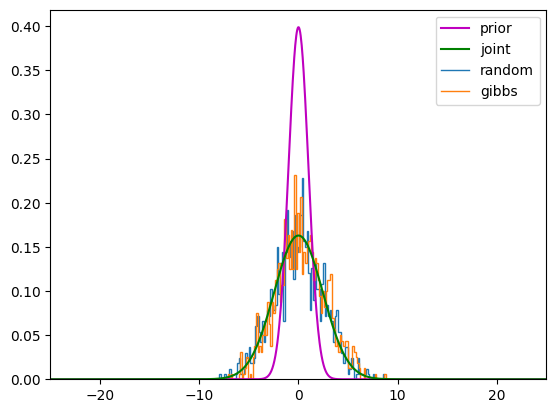

In [1]:
import numpy as np
import torch
import mogptk
from tests.mcmc import likelihood

torch.manual_seed(1);

In [2]:
N = 100

np.random.seed(1)
X = np.random.rand(N,1)

t1 = (np.sin(2*np.pi*X)).reshape(N,1)
t2 = (-np.sin(2*np.pi*X)).reshape(N,1)
t = np.concatenate((t1, t2), axis=1)

idx = np.argsort(X, axis=0).flatten()
X = X[idx]
t = t[idx,:]
y = np.array(np.argmax(t, 1).reshape(-1,1), dtype=float)

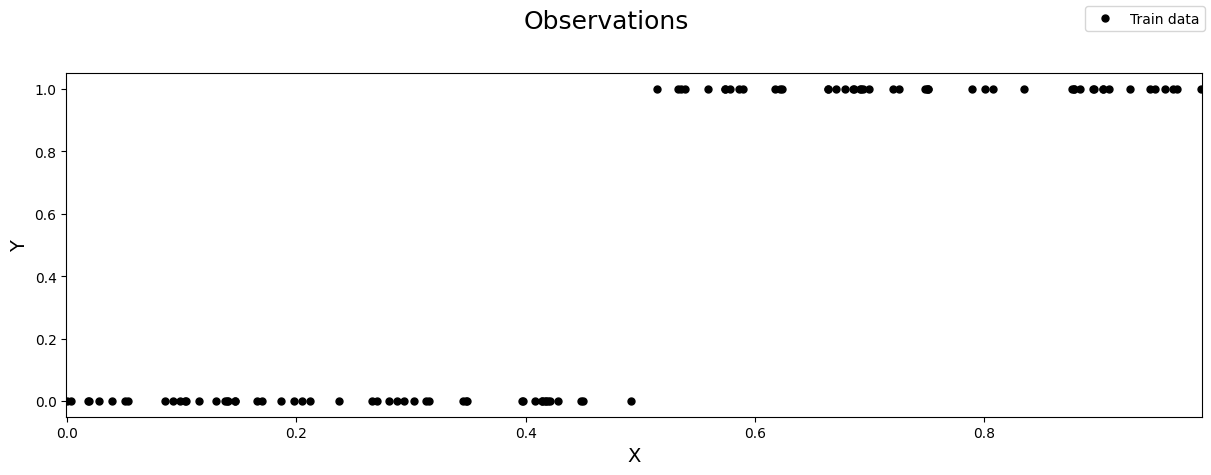

In [3]:
data = mogptk.DataSet(
    mogptk.Data(X, y),
)
data.plot(title="Observations");

In [ ]:
#Choose Bernoulli likelihood
likelihood = mogptk.gpr.BernoulliLikelihood()


#Choose inference
inference = mogptk.Hensman(likelihood=likelihood)
#Choose kernel
kernel = mogptk.gpr.SquaredExponentialKernel()

model = mogptk.Model(data, kernel, inference=inference)

In [7]:
model.plot_prediction(title='Untrained non-initialized model');

KeyboardInterrupt: 

Starting optimization using Adam
‣ Model: Hensman
  ‣ Kernel: SquaredExponentialKernel
  ‣ Likelihood: BernoulliLikelihood
‣ Channels: 1
‣ Parameters: 5152
‣ Training points: 100
‣ Iterations: 500


C:\Users\Usuario UTP\Documents\Doctorado\mogptk\mogptk\model.py:384: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return float(self.gpr.loss())


    0/500   0:00:01  loss=     99.4078  error=          50
  500/500   0:00:02  loss=     14.1885  error=     6.97302
Optimization finished in 2.832 seconds


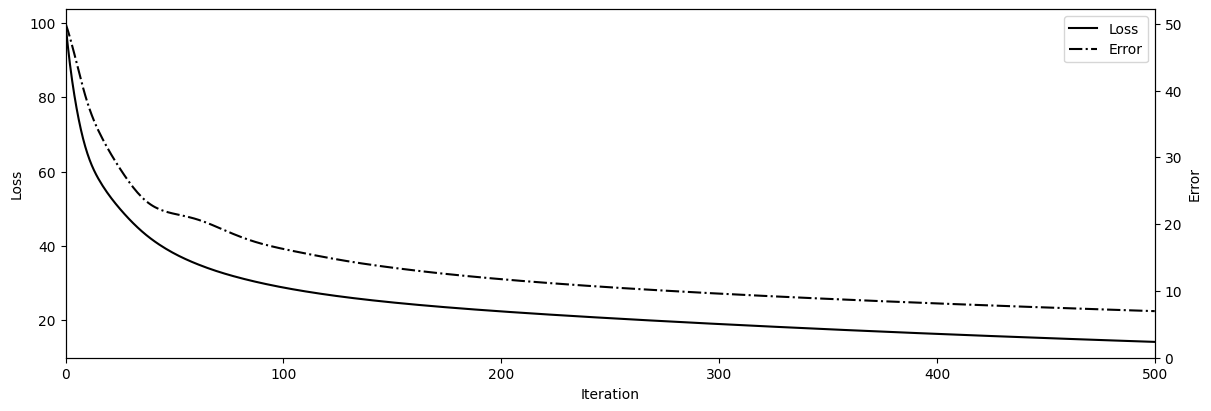

In [6]:
model.train(iters=500, verbose=True, error='mape', lr=0.02)
model.plot_losses();

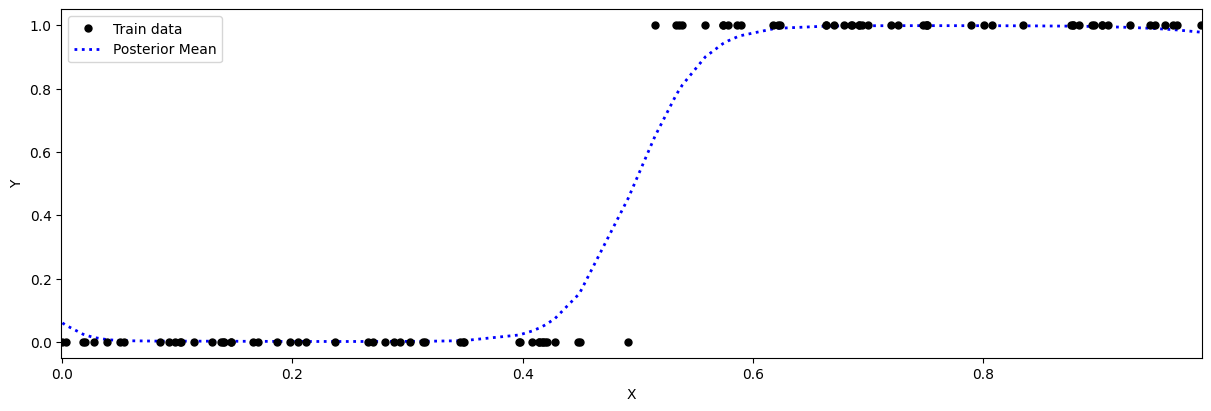

In [24]:
model.plot_prediction(n=100000);

In [28]:
model.print_parameters()

Name,Range,Value
Hensman.q_mu,"(-∞, ∞)",[[-1.25451646e+00] [-8.20391013e-01] [-4.34199824e-01] [-1.62564851e-01] [-6.73943977e-01] [-3.69206920e-01] [-2.43552063e-01] [-1.43775169e-01] [-4.38990263e-01] [-1.22155415e-01] [-1.02236956e-01] [-7.23730956e-02] [-4.38560162e-02] [-4.97405179e-02] [ 1.53772386e-02] [ 5.12092086e-02] [ 3.79946413e-02] [ 3.37923693e-02] [ 9.88854109e-02] [ 6.01737592e-02] [ 2.55668278e-01] [ 1.28206069e-01] [ 2.64073383e-01] [ 2.64815874e-01] [ 2.21107634e-01] [ 2.65547353e-01] [ 5.92322282e-01] [ 6.21282531e-01] [ 2.31033683e-01] [ 4.18944634e-01] [ 3.83074134e-01] [ 3.28302356e-01] [ 3.67461158e-01] [ 3.93075719e-01] [ 2.07831989e-01] [ 5.93911413e-01] [ 1.67827043e-01] [ 1.15768575e-01] [ 6.49980759e-01] [ 8.30809554e-02] [ 2.16869940e-01] [ 2.04323891e-01] [ 1.13253610e-01] [ 1.21455642e-01] [ 8.96520261e-02] [ 9.64357880e-02] [ 1.02175443e-01] [ 1.76381318e-01] [ 2.92616914e-01] [ 1.05387034e-01] [ 3.02248630e-01] [ 2.09764547e-01] [ 1.74516854e-01] [ 6.99614732e-02] [ 6.11941387e-02] [ 1.65184543e-01] [ 1.28652813e-01] [ 4.72511784e-02] [ 5.50528714e-02] [ 8.99986254e-02] [ 6.96907023e-02] [ 1.75278457e-01] [ 6.01465533e-02] [ 4.05870744e-02] [ 1.61662935e-01] [ 2.73349467e-02] [ 4.57760752e-02] [ 6.71552220e-02] [ 6.41791722e-02] [ 4.06741363e-02] [ 4.81355912e-02] [ 3.23410863e-02] [ 3.08054662e-02] [ 4.16990757e-02] [ 8.22840511e-02] [ 3.87319096e-02] [ 6.09434909e-02] [ 2.26680319e-02] [ 1.45018430e-02] [ 1.03858685e-02] [ 6.27974207e-02] [ 2.27025278e-02] [ 1.61137697e-02] [ 2.83919194e-02] [ 1.97793697e-02] [ 3.10631401e-03] [ 1.74257458e-03] [ 3.09304652e-03] [ 5.56522239e-03] [ 2.93810464e-03] [ 3.19727218e-03] [ 1.78364404e-03] [ 1.90466584e-03] [ 2.77957431e-03] [ 1.62761413e-03] [ 6.52940579e-04] [ 5.11341792e-04] [ 3.61241823e-04] [ 2.43273268e-04] [ 2.00780157e-04]]
Hensman.q_sqrt,"(-∞, ∞)",[[ 0.63519126 0. 0. ... 0. 0. 0. ] [-2.38530561 0.98904706 0. ... 0. 0. 0. ] [-0.26385968 -2.37603545 0.9995208 ... 0. 0. 0. ] ... [-0.89435423 -1.93835421 -1.11183419 ... 0.99999969 0. 0. ] [-0.82352515 -2.1183423 -1.4152133 ... -0.70428487 0.99999973 0. ] [-0.60135371 -3.05328701 -2.88481372 ... -0.52134128 -0.66260272 0.99999894]]
Hensman.Z,fixed,[[1.14374817e-04] [2.87032703e-03] [1.82882773e-02] [1.93669579e-02] [2.73875932e-02] [3.90547832e-02] [4.99534589e-02] [5.33625451e-02] [8.50442114e-02] [9.23385948e-02] [9.83468338e-02] [1.02334429e-01] [1.03226007e-01] [1.14745973e-01] [1.30028572e-01] [1.37474704e-01] [1.39276347e-01] [1.40386939e-01] [1.46728575e-01] [1.46755891e-01] [1.65354197e-01] [1.69830420e-01] [1.86260211e-01] [1.98101489e-01] [2.04452250e-01] [2.11628116e-01] [2.37026980e-01] [2.65546659e-01] [2.69927892e-01] [2.80443992e-01] [2.87775339e-01] [2.93614148e-01] [3.02332573e-01] [3.13424178e-01] [3.15515631e-01] [3.45560727e-01] [3.47765860e-01] [3.48898342e-01] [3.96767474e-01] [3.97676837e-01] [4.08136803e-01] [4.14055988e-01] [4.14179270e-01] [4.17022005e-01] [4.17304802e-01] [4.19194514e-01] [4.21107625e-01] [4.28091190e-01] [4.47893526e-01] [4.49912133e-01] [4.91573159e-01] [5.14889112e-01] [5.33165285e-01] [5.35896406e-01] [5.38816734e-01] [5.58689828e-01] [5.73679487e-01] [5.74117605e-01] [5.78389614e-01] [5.86555041e-01] [5.89305537e-01] [6.17144914e-01] [6.21695720e-01] [6.23672207e-01] [6.63441498e-01] [6.63794645e-01] [6.70467510e-01] [6.78835533e-01] [6.85219500e-01] [6.86500928e-01] [6.91877114e-01] [6.92322616e-01] [6.94400158e-01] [6.99758360e-01] [7.20324493e-01] [7.25997985e-01] [7.48165654e-01] [7.50144315e-01] [7.50812103e-01] [7.50942434e-01] [7.89279328e-01] [8.00744569e-01] [8.07391289e-01] [8.34625672e-01] [8.76389152e-01] [8.78117436e-01] [8.78142503e-01] [8.83306091e-01] [8.94606664e-01] [8.95886218e-01] [9.03379521e-01] [9.03401915e-01] [9.08595503e-01] [9.27508580e-01] [9.44594756e-01] [9.49489259e-01] [9.57889530e-01] [9.64840047e-01] [9.68261576e-01] [9.88861089e-01]]
SquaredExponentialKernel.magnitude,"[1e-08, ∞)",4.172376616400778
SquaredExpone